In [1]:
from openpiv import tools, pyprocess, validation, filters, scaling
from openpiv import preprocess as piv_pre

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import io
from PIL import Image
from IPython.display import Image as IPyImage, display
from scipy.signal import correlate
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import sys
sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/PIV/')   
import xarray as xr
import imageio
import pathlib
import cmcrameri.cm as cm
import pandas as pd

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

In [2]:
# For plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
mplstyle.use(['ggplot', 'fast'])

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12

from matplotlib.transforms import ScaledTranslation
from matplotlib.colors import LinearSegmentedColormap
from cmocean import cm as cmo
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# Particle Image Velocimetry
#### Kjersti Stangeland, Spring 2026
**Analyzing**:
* f = 1.4 Hz
* A = 0.3 V
* D = 0.2 m
* H = 0.15 m

Run 3 out of 3

In [3]:
# Opening frames needed for analyzing two wave periods
ims = np.linspace(1250, 1516, 267)  # Adjusted to cover three periods (1250 to 1516)
frames = {}

for im in ims:
    im_int = int(im)
    img = tools.imread(f'/Users/kjesta/Desktop/LABDATA/PIV/f14a03/bitmap3/image_p{im_int}.bmp')
    frames[im_int] = img

In [4]:
T = 1/1.4  # wave period, seconds
fps = 125  # frames per second
dt = 1/fps  # time between frames, seconds
fpp = fps*T  # frames per period
images_needed = int(3*fpp)

print(f"Frames per period: {fpp:.2f}")
print(f"Time between frames: {dt:.4f} s")
print(f"Total images needed for three periods: {images_needed}")
print(f"Frames opened: {len(frames)}")

Frames per period: 89.29
Time between frames: 0.0080 s
Total images needed for three periods: 267
Frames opened: 267


In [5]:
timestamps = [i * dt + 10 for i in list(frames.keys())] # timestamps for one period, starting at 10 seconds

In [6]:
'''
Cutting out mid part of image. 
Want to avoid the free surface as the edge effects there
distort the velocity field.
I also match the indices to the reference photo to be sure the scaling is correct.
'''
y_min = 1080
y_max = 1490

x_min = 15
x_max = 1250

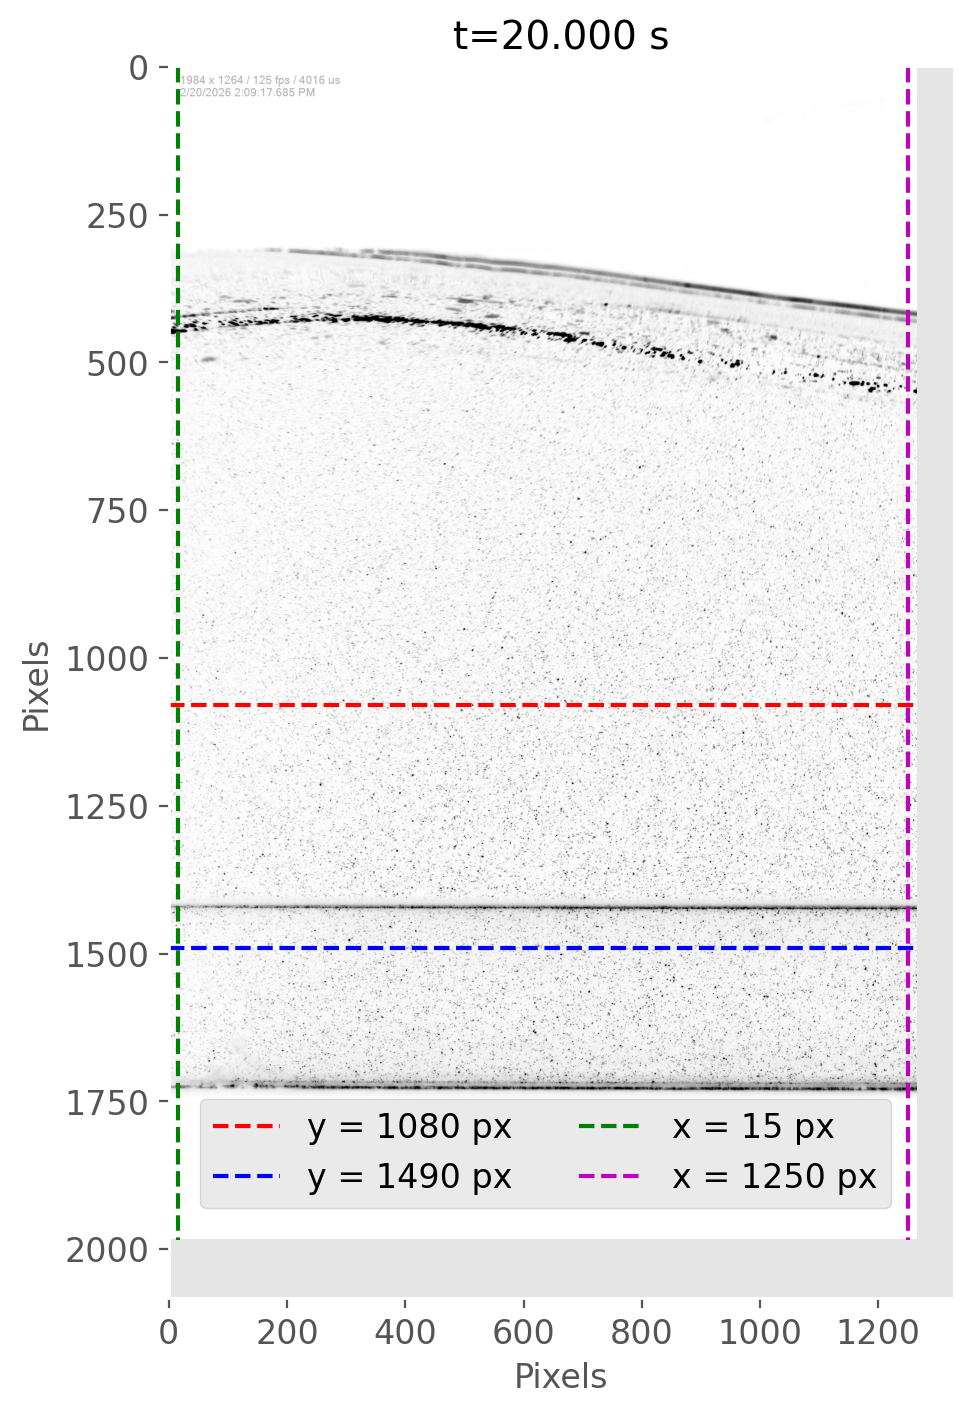

In [7]:
fig, ax =plt.subplots(figsize=(10,8))
ax.imshow(frames[1250], cmap='gray_r')
ax.hlines(y=y_min, xmin=0, xmax=frames[1250].shape[1], colors='r', linestyles='--', label=f'y = {y_min} px')
ax.hlines(y=y_max, xmin=0, xmax=frames[1250].shape[1], colors='b', linestyles='--', label=f'y = {y_max} px')
ax.vlines(x=x_min, ymin=0, ymax=frames[1250].shape[0], colors='g', linestyles='--', label=f'x = {x_min} px')
ax.vlines(x=x_max, ymin=0, ymax=frames[1250].shape[0], colors='m', linestyles='--', label=f'x = {x_max} px')
ax.set_title(f't={timestamps[0]:.3f} s')
ax.legend(loc='lower center', ncol=2, bbox_to_anchor=(0.48, 0.06))
ax.set_xlabel('Pixels')
ax.set_ylabel('Pixels')

ax.grid()
#fig.legend(title='Region of analysis', loc='lower center', bbox_to_anchor=(0.5, 0.92), ncol=2)

In [8]:
# Zoom in on area of interest
# Ignoring the surface and the bottom of the frame
zoom_frames = {}
for key in frames.keys():
    zoom_frames[key] = frames[key][y_min:y_max, x_min:x_max]

In [9]:
plate_top_index = 343

In [10]:
# Load reference image
reference = tools.imread('/Users/kjesta/Desktop/LABDATA/PIV/reference_p29.bmp')

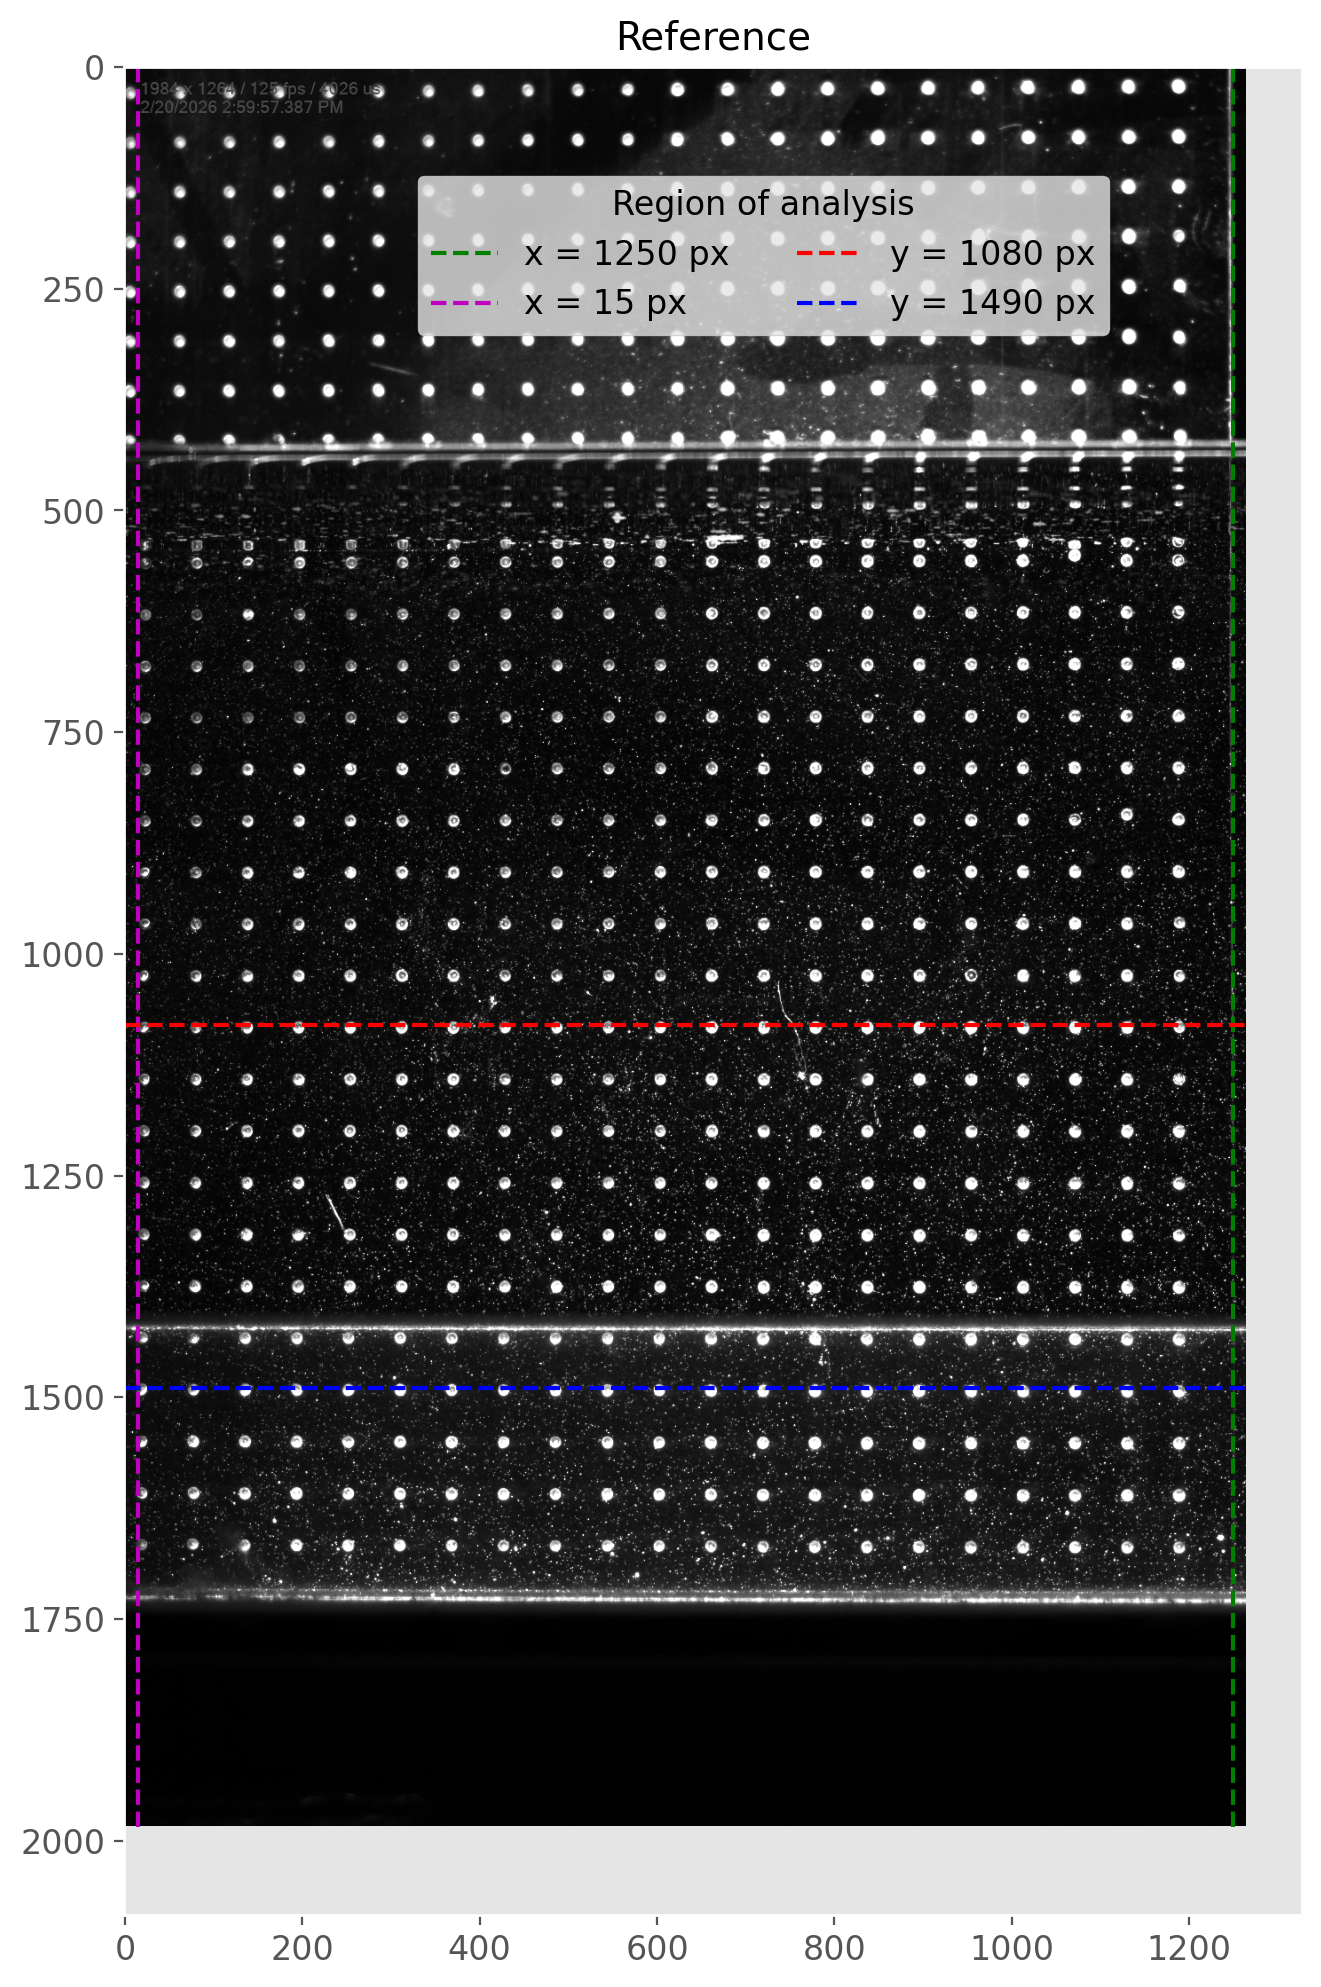

In [11]:
fig, ax =plt.subplots(1, figsize=(12, 12))
ax.imshow(reference, cmap='gray')
ax.vlines(x=x_max, ymin=0, ymax=reference.shape[0], colors='g', linestyles='--', label=f'x = {x_max} px')
ax.vlines(x=x_min, ymin=0, ymax=reference.shape[0], colors='m', linestyles='--', label=f'x = {x_min} px')
ax.hlines(y=y_min, xmin=0, xmax=reference.shape[1], colors='r', linestyles='--', label=f'y = {y_min} px')
ax.hlines(y=y_max, xmin=0, xmax=reference.shape[1], colors='b', linestyles='--', label=f'y = {y_max} px')
ax.legend(title='Region of analysis', loc='upper right', bbox_to_anchor=(0.85, 0.95), ncol=2)
ax.set_title('Reference')
ax.grid()

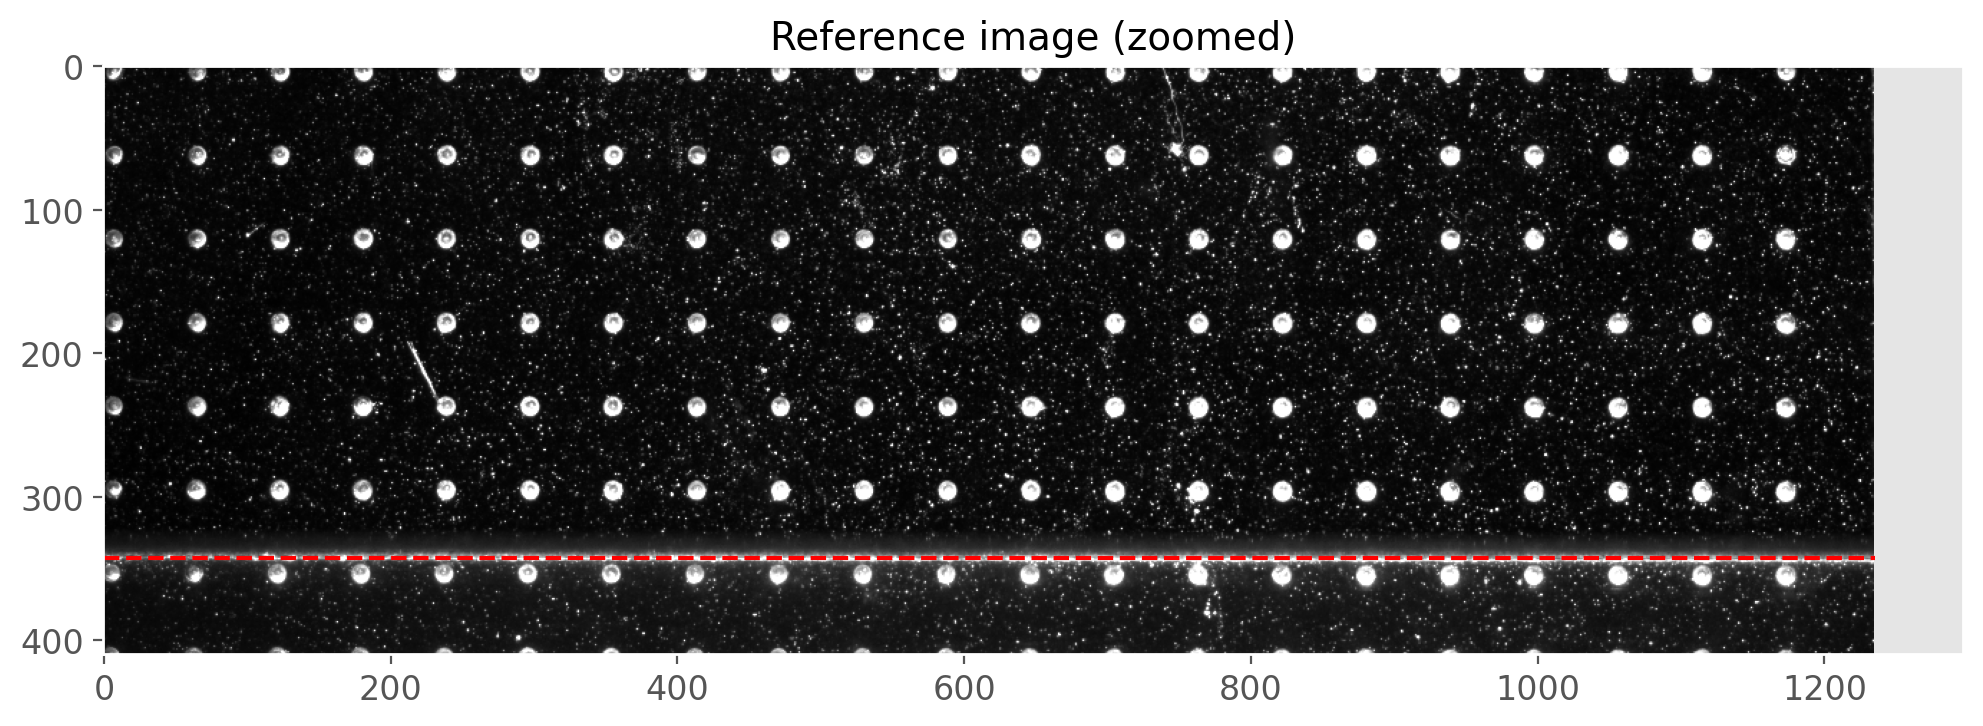

In [12]:
# Zoom in on reference image
reference_zoom = reference[y_min:y_max, x_min:x_max]

fig, ax =plt.subplots(1, figsize=(12,6))
ax.imshow(reference_zoom, cmap='gray')
ax.set_title('Reference image (zoomed)')
ax.hlines(y=plate_top_index, xmin=0, xmax=reference_zoom.shape[1], colors='r', linestyles='--')
ax.grid()

In [13]:
# Distance between pixel 15 and 1250 (in horizontal direction)
x_m = 0.21
# Distance between pixel 1250 and 1725 (in vertical direction)
y_m = 0.07

# Calculate pixel to m scaling factors
x_scale = (x_max - x_min) / x_m  # pixel per m
y_scale = (y_max - y_min) / y_m  # pixel per m

print(f"x_scale = {x_scale:.3f} px/m, y_scale = {y_scale:.3f} px/m")
print(f'Percentage difference: {(x_scale-y_scale)/y_scale * 100:.2f}%')

# Average if appropriate
scaling_factor = (x_scale + y_scale) / 2
print(f"Average scaling factor: {scaling_factor:.3f} px/m")

x_scale = 5880.952 px/m, y_scale = 5857.143 px/m
Percentage difference: 0.41%
Average scaling factor: 5869.048 px/m


In [14]:
# Crop frames to region of interest
ims = np.linspace(1250, 1516, 267)
cropped_frames = {}

for im in ims:
    cropped_frames[int(im)] = frames[int(im)][y_min:y_max, x_min:x_max]

In [15]:
# Removing static background
static = np.median(list(cropped_frames.values()), axis=0)
cleaned_frames = {}
for key in cropped_frames.keys():
    cleaned_frames[key] = cropped_frames[key] - static

In [16]:
enhanced_frames = {}
for key in cleaned_frames.keys():
    enhanced_frames[key] = piv_pre.contrast_stretch(img=cleaned_frames[key])

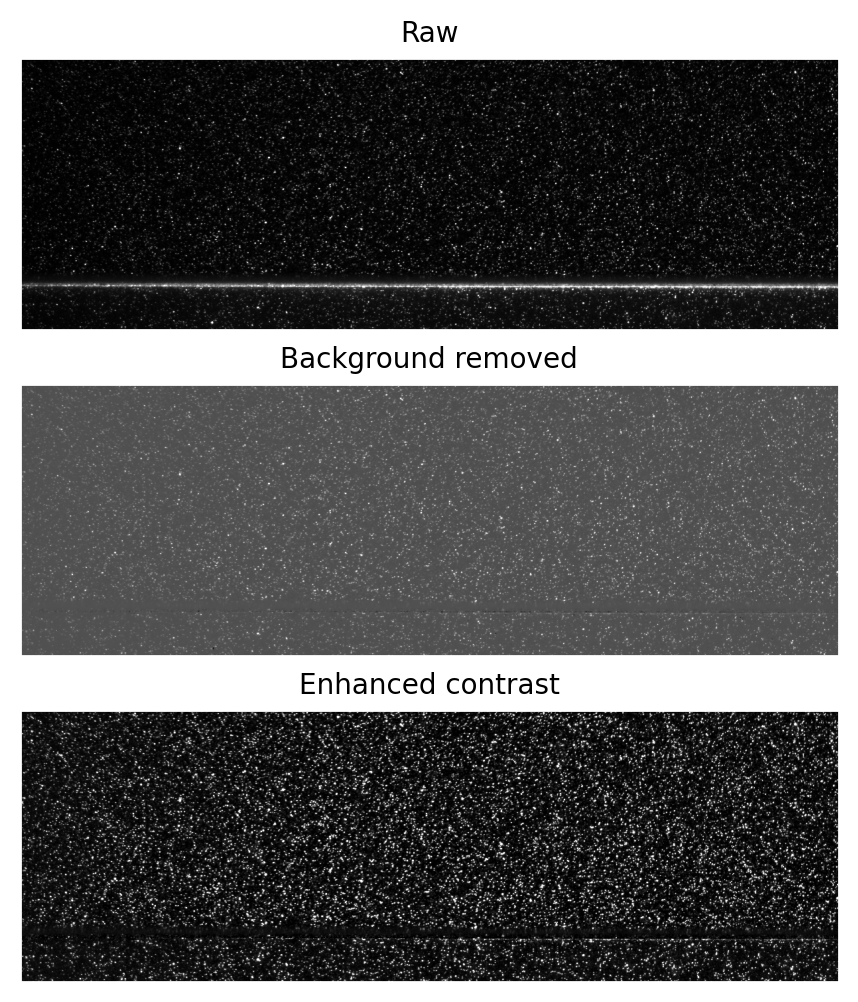

In [17]:
fig, ax =plt.subplots(3,1, figsize=(10, 6), sharex=True)

ax[0].imshow(cropped_frames[1250], cmap='gray')
ax[0].set_title(f't={timestamps[0]:.3f} s ')

ax[1].imshow(cleaned_frames[1250], cmap='gray')

ax[2].imshow(enhanced_frames[1250], cmap='gray')

titles = ['Raw', 'Background removed', 'Enhanced contrast']
for i in range(3):
    ax[i].set_title(titles[i], fontsize=10)
    ax[i].set_xticks([])
    ax[i].set_yticks([])


ax[0].grid()
ax[1].grid()
ax[2].grid()

In [167]:
#del cleaned_frames
del cropped_frames
del frames
del zoom_frames

Window size: (16, 32) px, Stepsize: 3
Displacement (x, y): (-10, -3) pixels


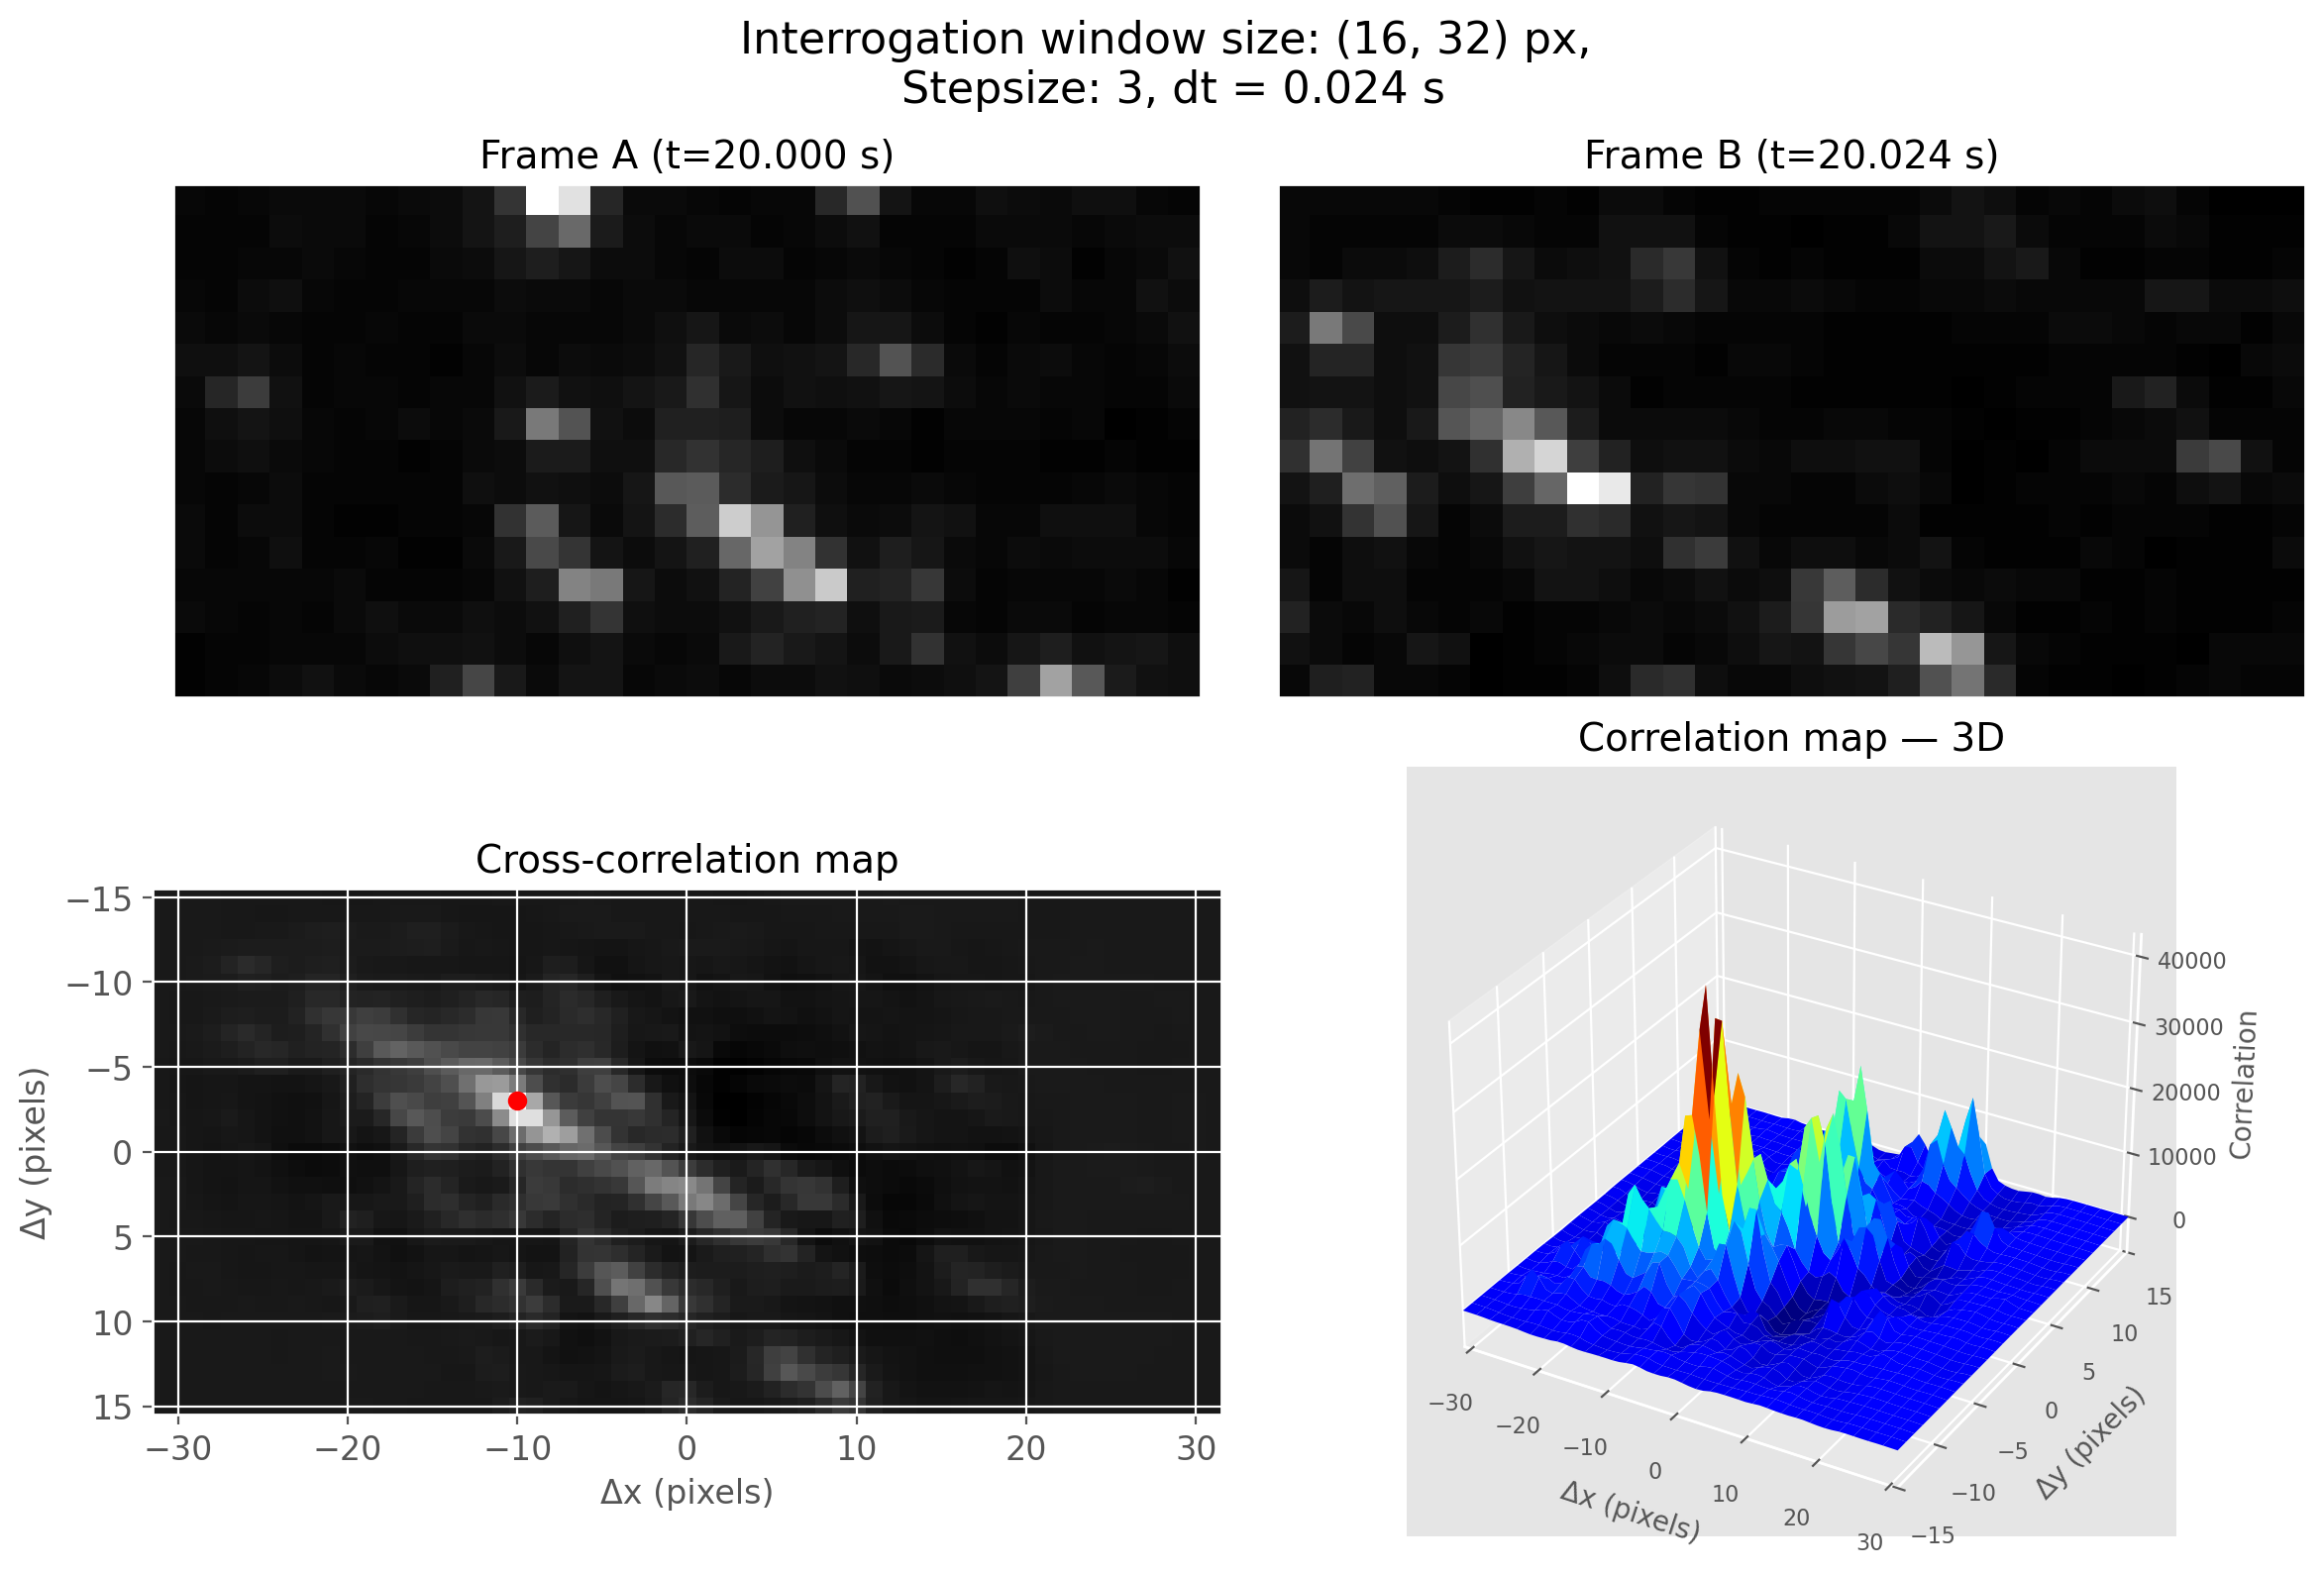

In [168]:
from scipy.signal import correlate
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec

window_sizes = [(16, 32)]
stepsizes    = [3]

for win_h, win_w in window_sizes:
    for s in stepsizes:
        print(f"Window size: ({win_h}, {win_w}) px, Stepsize: {s}")
        # Top corner
        win_a = cleaned_frames[1250][:win_h, :win_w]
        win_b = cleaned_frames[1250 + s][:win_h, :win_w]

        frame_a = 1250
        frame_b = 1250 + s
        time_a  = timestamps[0]
        time_b  = timestamps[0 + s]
        dt      = time_b - time_a 
    
        cross_corr = correlate(win_b, win_a, mode='full')

        n_rows, n_cols = cross_corr.shape
        win_h, win_w   = win_a.shape  # should match loop values

        # Displacement coordinates
        dx = np.arange(-win_w + 1, win_w)   # size 2*win_w - 1
        dy = np.arange(-win_h + 1, win_h)   # size 2*win_h - 1
        Xc, Yc = np.meshgrid(dx, dy)

        # Peak index in array coordinates
        y_idx, x_idx = np.unravel_index(cross_corr.argmax(), cross_corr.shape)

        # Convert peak index to displacement
        disp_x = x_idx - (n_cols // 2)
        disp_y = y_idx - (n_rows // 2)

        fig = plt.figure(figsize=(12, 8))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.5])
        ax_a = fig.add_subplot(gs[0, 0])
        ax_b = fig.add_subplot(gs[0, 1])
        ax_corr = fig.add_subplot(gs[1, 0])
        ax_3d = fig.add_subplot(gs[1, 1], projection="3d")

        # Top row: interrogation windows
        ax_a.imshow(win_a, cmap='gray')
        ax_a.set_title(f'Frame A (t={time_a:.3f} s)')
        ax_a.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax_a.grid()

        ax_b.imshow(win_b, cmap='gray')
        ax_b.set_title(f'Frame B (t={time_b:.3f} s)')
        ax_b.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax_b.grid()

        # 2D cross-correlation map in displacement coordinates
        # Note: y-extent reversed so that positive dy is up
        extent = [dx[0] - 0.5, dx[-1] + 0.5,
                  dy[-1] + 0.5, dy[0] - 0.5]

        ax_corr.imshow(cross_corr, cmap='gray', extent=extent, origin='upper')
        ax_corr.set_title('Cross-correlation map')
        ax_corr.set_xlabel('Δx (pixels)')
        ax_corr.set_ylabel('Δy (pixels)')

        # Plot peak at (disp_x, disp_y)
        ax_corr.plot(disp_x, disp_y, "ro")

        # 3D plot
        fig.delaxes(ax_3d)  # Remove empty subplot
        ax_3d = fig.add_subplot(2, 2, 4, projection="3d")
        ax_3d.set_title('Correlation map — 3D')
        ax_3d.plot_surface(Xc, Yc, cross_corr, cmap='jet', linewidth=0.2)
        ax_3d.set_xlabel('Δx (pixels)', fontsize=10)
        ax_3d.set_ylabel('Δy (pixels)', fontsize=10)
        ax_3d.set_zlabel('Correlation', fontsize=10)
        ax_3d.set_xlim(dx[0], dx[-1])
        ax_3d.set_ylim(dy[0], dy[-1])
        ax_3d.tick_params(axis='both', labelsize=8)
        ax_3d.tick_params(axis='z', labelsize=8)


        print(f"Displacement (x, y): ({disp_x}, {disp_y}) pixels")

        fig.suptitle(
            f"Interrogation window size: ({win_h}, {win_w}) px, \n"
            f"Stepsize: {s}, dt = {dt:.3f} s",
            fontsize=16
        )
        plt.tight_layout()

In [169]:
def depth_formatter(y_tick, pos):
        # depth: negative downward
        # Adding ashift the depth values so that it matches real water depth
        return f"{-(y_tick + 0.09):.2f}"

def x_phys_formatter(x_tick, pos):
        # Map image x → physical x (paddle at 8.06 m on the right)
        return f"{8.06 + (x_max - x_tick):.2f}"

In [170]:
# PIV parameters

window_size = (16, 32)  # interrogation window size (in pixels)
overlap = (window_size[0] // 2, window_size[1] // 2)  # overlap between interrogation windows (in pixels)
search_area_size = window_size # search area size (in pixels)
stepsize = 3  # how many frames to skip between PIV analyses
threshold = 1.2  # sig2noise threshold for validation
max_iter = 10  
kernel_size = 2

dt = 1/fps

print(f'Time between frames for PIV: {stepsize * dt:.3f} s')

Time between frames for PIV: 0.024 s


* 16 px in y direction, requires more than 6.25% displacement relative to window size to be more than one pixel
* 32 px in y direction, requires more than 1.33% displacement relative to window size to be more than one pixel

In [ ]:
# Lists for storing vertical velocity
# and vertical velocity gradient around the plates 
times = []
x_top = None
flag_frac_list = [] # list of fraction of vectors flagged as outliers (for whole field, not just plate top)

# lists for full 2D fields over the whole domain
U_full_list = []       # u field at all z,x
W_full_list = []       # v field (vertical velocity) at all z,x
CURL_full_list = []    # vorticity field at all z,x
DUDX_full_list = []    # du/dx field at all z,x
DWDZ_full_list = []    # dw/dz field at all z,x

# To store 1D coordinates for x and z (from x,y meshgrid)
X_coords = None
Y_coords = None

for key in range(1250, 1516-stepsize, stepsize):
    # Run PIV
    frame_a = enhanced_frames[key]
    frame_b = enhanced_frames[key + stepsize]
    
    # Time indices for the two frames used in PIV
    idx_a = key - 1250
    idx_b = idx_a + stepsize

    time_a = timestamps[idx_a]
    time_b = timestamps[idx_b]

    dt = time_b - time_a

    # Perform PIV analysis
    u, v, sig2noise = pyprocess.extended_search_area_piv(
        frame_a, frame_b,
        window_size=window_size,
        overlap=overlap,
        dt=dt*stepsize,
        search_area_size=search_area_size
    )

    # Get coordinates
    x, y = pyprocess.get_rect_coordinates(
        frame_a.shape,
        window_size,
        overlap
    )
    # 1) Signal-to-noise validation
    u, v, mask = validation.sig2noise_val(u, v, sig2noise, threshold=threshold)
    
    # 2) Local median validation
    u, v, mask = validation.local_median_val(
        u, v, u_threshold=50, v_threshold=50
    )

    flag_frac = np.mean(mask)

    # 3) Replace outliers by local mean
    u, v = filters.replace_outliers(
        u, v,
        method='localmean',
        max_iter=max_iter,
        kernel_size=kernel_size
    )

    # 4) Scale to physical units
    x, y, u, v = scaling.uniform(x, y, u, v, scaling_factor=scaling_factor) 

    # Calculate vorticity and velocity gradients
    curl_u = np.gradient(u, axis=0) # du/dz
    curl_w = np.gradient(v, axis=1) # dw/dx
    curl = curl_u - curl_w  # vorticity
    grad_u = np.gradient(u, axis=1) # du/dx
    grad_w = np.gradient(v, axis=0) # dw/dz

    # --- store full fields for NetCDF ---
    if X_coords is None or Y_coords is None:
        # extract 1D coordinates from meshgrid
        X_coords = x[0, :].copy()   # (Nx,)
        Y_coords = y[:, 0].copy()   # (Ny,)

    U_full_list.append(u.copy())        # (Ny, Nx)
    W_full_list.append(v.copy())        # (Ny, Nx)
    CURL_full_list.append(curl.copy())  # (Ny, Nx)
    DUDX_full_list.append(grad_u.copy())# (Ny, Nx)
    DWDZ_full_list.append(grad_w.copy())# (Ny, Nx)
    times.append(time_b)

    # Find location of top of plates in physical units (m) and corresponding index in y array
    plate_top_m = plate_top_index/scaling_factor
    y_idx_plate_top = (np.abs(y[:, 0] - plate_top_m)).argmin()

    # Find vertical velocity in the region of the plates
    # Exact plate top
    w = np.asarray(v[y_idx_plate_top, :])
    dwdz = np.asarray(grad_w[y_idx_plate_top, :])
    no_w_vec = np.shape(v[y_idx_plate_top, :])
    # One pixel above plate top
    w_top = np.asarray(v[y_idx_plate_top - 1, :])
    dwdz_top = np.asarray(grad_w[y_idx_plate_top - 1, :])
    # One pixel under plate top
    w_under = np.asarray(v[y_idx_plate_top + 1, :])
    dwdz_under = np.asarray(grad_w[y_idx_plate_top + 1, :])

    # For plotting, mean vertical velocity at plate top to show in legend
    w_bar = np.mean(v[y_idx_plate_top, :])

    # --- Diagnostic print (displacement in pixels) ---
    # Displacement in meters
    dx = u * dt
    dy = v * dt

    # Convert to pixels
    dx_pix = dx * scaling_factor
    dy_pix = dy * scaling_factor

    # Magnitude of displacement (pixels)
    disp_pix = np.sqrt(dx_pix**2 + dy_pix**2)

    # Mean and max displacement
    mean_disp = np.mean(disp_pix)
    max_disp = np.max(disp_pix)

    if mean_disp < 1:
        print(f"UH OH! Frame {key} to {key+stepsize}: mean displacement less than 1 px.")
    
    if max_disp > window_size[0] or max_disp > window_size[1]:
        print(f"UH OH! Frame {key} to {key+stepsize}: max displacement exceeds window size.")

    print(f"Flagged fraction: {flag_frac:.3f}")
    print('----------------------------------------')

    # ---------------
    # PLOTTING
    # ---------------
    # Origin (0,0) is at the top left corner of the enhanced image, 
    # meaning x increases to the right, y increases downwards
    # For plotting, I want to show the location in the tank, so I modify x to match location in the tank
    # and y to be negative and descending downwards to be depth

    # Decimal for colorbars
    kwargs = {'format': '%.3f'}

    x_max = x.max()
    y_min = y.min()

    # Plot the velocity field
    fig, ax = plt.subplots(2, 1, figsize=(8,6))

    ax[0].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))

    # Colorbar limits for vertical velocity
    vmin = -0.02
    vmax = 0.02
    
    # Colorbar limits for velocity magnitude
    umin = 0
    umax = 0.03

    # Subsampling steps for quiver plot
    step_x = 2
    step_z = 4

    # Filled contour of velocity magnitude
    im = ax[0].contourf(x, y, np.sqrt(u**2 + v**2), cmap=cm.imola, alpha=0.6, levels=np.linspace(umin, umax, 41), extend='max')

    # Quiver plot of velocity vectors
    im1 = ax[0].quiver(x[::step_z, ::step_x], y[::step_z, ::step_x], -u[::step_z, ::step_x], v[::step_z, ::step_x], color='white')
    cbar = plt.colorbar(im, label='Velocity magnitude [m/s]', shrink=0.8, **kwargs)

    ax[0].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')
    ax[0].set_title(f't={timestamps[idx_b]:.3f} s')
    ax[0].grid()
    ax[0].legend(loc='upper left')

    # Filled contour plot of vertical velocity
    im1 = ax[1].contourf(x, y, v, cmap=cm.vik, alpha=0.6, levels=np.linspace(vmin, vmax, 41), extend='both')

    cbar3 = plt.colorbar(
        im1, extend='both',
        label='Vertical velocity [m/s]', shrink=0.8, **kwargs
    )

    ax[1].grid()
    ax[1].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linewidth=1, linestyles='--',
                 label=rf'$\bar w$ = {w_bar:.4f} m/s')

    ax[1].legend(loc='upper left')

    for a in ax:
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.set_xlabel("x [m]")
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.set_ylabel("z [m]")

    plt.savefig(f'/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/final_figs/f14a03/vel_field_{key}_r3.png', dpi=200)
    plt.close(fig)
   
    # Plot the vorticity and velocity gradients
    vmin = -0.005
    vmax = 0.005
    vlev = np.linspace(vmin, vmax, 41)

    umin = -0.005
    umax = 0.005
    ulev = np.linspace(umin, umax, 41)

    wmin = -0.005
    wmax = 0.005
    wlev = np.linspace(wmin, wmax, 41)

    # Vorticity
    fig, ax = plt.subplots(3, 1, figsize=(8,8))
    im = ax[0].contourf(x, y, curl, alpha=0.6, levels=vlev, cmap=cm.vik, extend='both')
    ax[0].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))
    cbar = plt.colorbar(im, ax=ax[0], label='Vorticity [1/s]', pad=0.01, shrink=0.9, **kwargs)
    ax[0].grid()
    ax[0].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')

    # Velocity gradients
    im = ax[1].contourf(x, y, grad_u, alpha=0.6, levels=ulev, cmap=cm.vik, extend='both')
    cbar = plt.colorbar(im, ax=ax[1], label=r'$\partial u / \partial x$ [1/s]', pad=0.01, shrink=0.9, **kwargs)
    ax[1].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[1].grid()
    ax[1].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')

    im = ax[2].contourf(x, y, grad_w, alpha=0.6, levels=wlev, cmap=cm.vik, extend='both')
    cbar = plt.colorbar(im, ax=ax[2], label=r'$\partial w / \partial z$ [1/s]', pad=0.01, shrink=0.9, **kwargs)
    ax[2].imshow(enhanced_frames[key+1], cmap='gray_r', alpha=0.6, extent=(x.min(), x.max(), y.max(), y.min()))
    ax[2].grid()
    ax[2].hlines(y=plate_top_m, xmin=x.min(), xmax=x.max(), colors='black', linestyles='--', linewidth=1, label='Top of plates')
    fig.suptitle(f't = {timestamps[idx_b]:.3f} s')

    for a in ax:
        a.xaxis.set_major_formatter(FuncFormatter(x_phys_formatter))
        a.set_xlabel("x [m]")
        a.yaxis.set_major_formatter(FuncFormatter(depth_formatter))
        a.set_ylabel("z [m]")
        
    plt.tight_layout() 
    
    plt.savefig(f'/Users/kjesta/Desktop/LABDATA/PIV/Results/zoom/Final/final_figs/f14a03/curl_grad_{key}_r3.png', dpi=200)
    plt.close(fig)

# Convert lists to arrays for saving
time = np.array(times)
flag_frac_arr = np.array(flag_frac_list)

# Full 3D fields (time, z, x)
U_full = np.stack(U_full_list, axis=0)       # (Nt, Nz, Nx)
W_full = np.stack(W_full_list, axis=0)       # (Nt, Nz, Nx)
CURL_full = np.stack(CURL_full_list, axis=0) # (Nt, Nz, Nx)
DUDX_full = np.stack(DUDX_full_list, axis=0) # (Nt, Nz, Nx)
DWDZ_full = np.stack(DWDZ_full_list, axis=0) # (Nt, Nz, Nx)

import xarray as xr

ds = xr.Dataset(
    data_vars=dict(
        # Full 3D fields
        u=(["time", "z", "x"], U_full),
        w=(["time", "z", "x"], W_full),          # vertical velocity field
        vorticity=(["time", "z", "x"], CURL_full),
        dudx=(["time", "z", "x"], DUDX_full),
        dwdz=(["time", "z", "x"], DWDZ_full),
    ),

    coords=dict(
        time=("time", time),
        x=("x", X_coords),
        z=("z", Y_coords),  # vertical coordinate (from y)
    ),
    attrs=dict(
        description="PIV results: full velocity fields and values along plate top",
        units_u="m s-1",
        units_w="m s-1",
        units_vorticity="s-1",
        units_dudx="s-1",
        units_dwdz="s-1",
        plate_top_m=float(plate_top_m),
        y_idx_plate_top=int(y_idx_plate_top),
    ),
)

ds.to_netcdf('/Users/kjesta/Desktop/LABDATA/PIV/results/zoom/Final/f14a03_rec_res_r3.nc')

/Users/kjesta/miniconda3/envs/masters/lib/python3.10/site-packages/scipy/ndimage/_filters.py:1963: RuntimeWarning: All-NaN slice encountered
  _nd_image.generic_filter(input, function, footprint, output, mode,


Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.001
----------------------------------------
Flagged fraction: 0.001
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
----------------------------------------
Flagged fraction: 0.000
-

In [ ]:
ds

<xarray.Dataset> Size: 13MB
Dimensions:    (time: 88, z: 50, x: 76)
Coordinates:
  * time       (time) float64 704B 20.02 20.05 20.07 20.1 ... 22.06 22.09 22.11
  * x          (x) float64 608B 0.002726 0.005452 0.008178 ... 0.2045 0.2072
  * z          (z) float64 400B 0.001363 0.002726 0.004089 ... 0.06679 0.06815
Data variables:
    u          (time, z, x) float64 3MB -0.02248 -0.02248 ... -0.01207 -0.01194
    w          (time, z, x) float64 3MB -0.004639 -0.004641 ... 0.006299 0.00639
    vorticity  (time, z, x) float64 3MB -2.612e-06 -2.811e-06 ... -3.978e-05
    dudx       (time, z, x) float64 3MB -3.169e-06 -3.559e-06 ... 0.0001258
    dwdz       (time, z, x) float64 3MB -2.273e-06 -2.489e-06 ... -2.481e-06
Attributes:
    description:      PIV results: full velocity fields and values along plat...
    units_u:          m s-1
    units_w:          m s-1
    units_vorticity:  s-1
    units_dudx:       s-1
    units_dwdz:       s-1
    plate_top_m:      0.0584421906693712
    y_idx_plate_top:  42